/tmp/ipykernel_2888/3405117624.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period="6mo")
[*********************100%***********************]  1 of 1 completed

--- Data for AAPL ---
Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2025-10-15  248.865646  251.340939  246.999209  249.015370  33893600
2025-10-16  246.979248  248.566220  244.663670  247.777729  39777000
2025-10-17  251.810028  252.897966  246.799589  247.548162  49147000
2025-10-20  261.741119  263.877063  255.143709  255.403208  90483000
2025-10-21  262.270111  264.785337  261.331897  261.381820  46695900


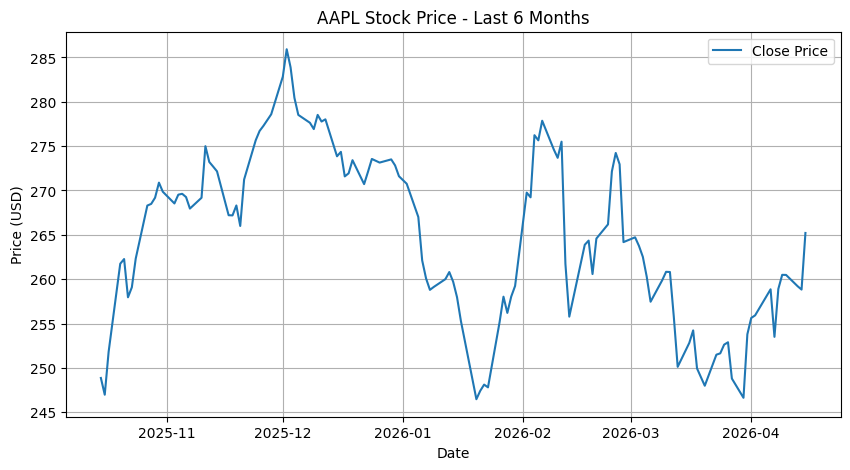

In [9]:
import yfinance as yf
import matplotlib.pyplot as plt

# Define the stock ticker (e.g., AAPL for Apple)
ticker = "AAPL"

# Fetch historical data for the last 6 months
data = yf.download(ticker, period="6mo")

# Display the first few rows to see the factors (Open, High, Low, Close, Volume)
print(f"--- Data for {ticker} ---")
print(data.head())

# Visualize the Closing Price over time
plt.figure(figsize=(10, 5))
plt.plot(data['Close'], label='Close Price')
plt.title(f'{ticker} Stock Price - Last 6 Months')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [3]:
import yfinance as yf
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1. DATA COLLECTION [cite: 23]
# We'll fetch 5 years of historical data for a technology stock
ticker_symbol = "AAPL"
raw_data = yf.download(ticker_symbol, start="2021-01-01", end="2026-01-01")

# 2. FEATURE EXTRACTION
# Keeping only the relevant features: Open, High, Low, Close, and Volume
df = raw_data[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

# 3. HANDLING MISSING VALUES
# Check for nulls and drop them to ensure data integrity
print(f"Missing values before cleaning:\n{df.isnull().sum()}")
df.dropna(inplace=True)

# 4. NORMALIZATION
# Stock prices and volume have different scales. We use MinMaxScaler
# to bring all values between 0 and 1 for better model training later.
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df)

# Convert back to a DataFrame for easy viewing
df_scaled = pd.DataFrame(scaled_data, columns=df.columns, index=df.index)

print("\n--- Preprocessed Data (First 5 Rows) ---")
print(df_scaled.head())

/tmp/ipykernel_2888/3247318304.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(ticker_symbol, start="2021-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed


Missing values before cleaning:
Price   Ticker
Open    AAPL      0
High    AAPL      0
Low     AAPL      0
Close   AAPL      0
Volume  AAPL      0
dtype: int64

--- Preprocessed Data (First 5 Rows) ---
Price           Open      High       Low     Close    Volume
Ticker          AAPL      AAPL      AAPL      AAPL      AAPL
Date                                                        
2021-01-04  0.081879  0.074072  0.059415  0.072557  0.416902
2021-01-05  0.055391  0.063442  0.068977  0.081573  0.265168
2021-01-06  0.048697  0.059519  0.057239  0.056723  0.456088
2021-01-07  0.052359  0.062816  0.065714  0.081067  0.304777
2021-01-08  0.075643  0.068501  0.079284  0.087434  0.290081


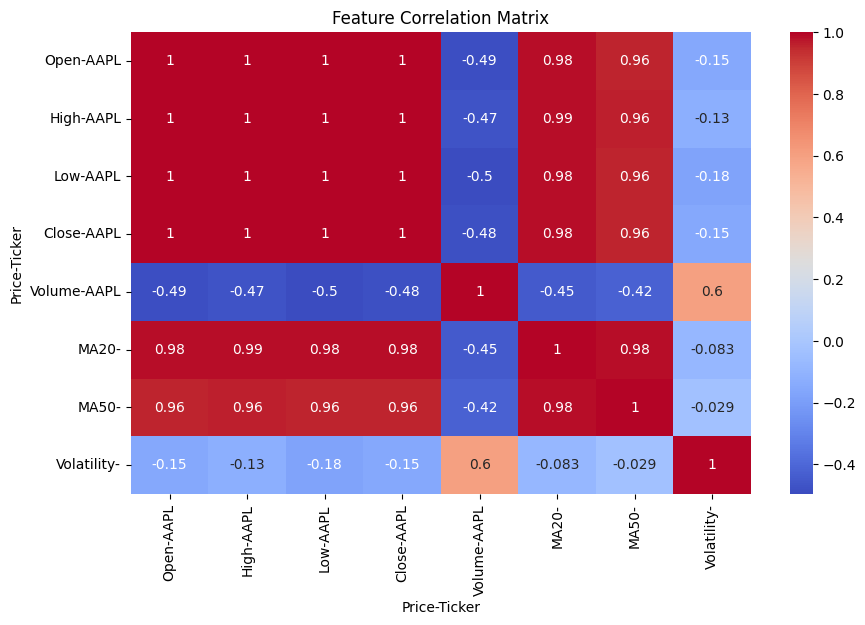

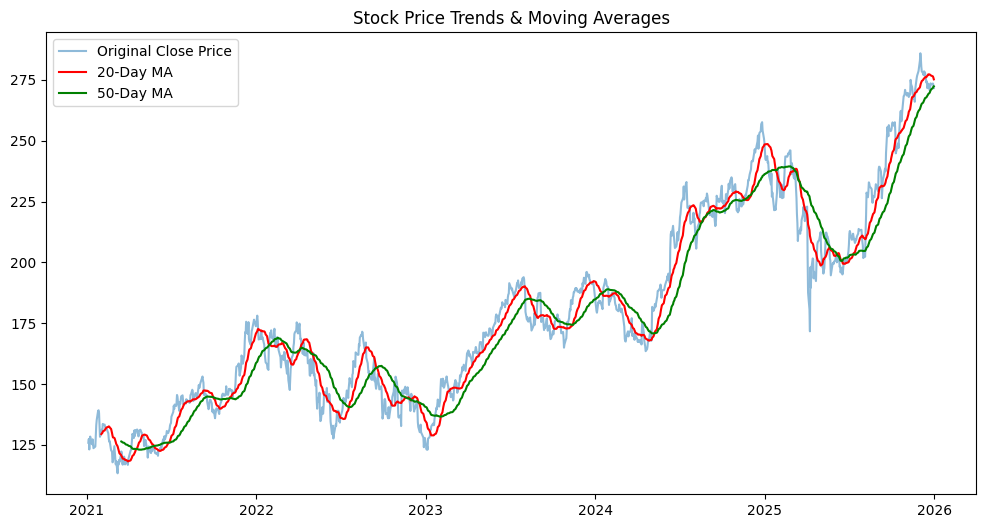

New Features Added. Dataset Shape: (1206, 8)


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' is your cleaned DataFrame from Week 2
# 1. FEATURE ENGINEERING: Creating Moving Averages
# Moving averages smooth out price data to identify the trend direction.
df['MA20'] = df['Close'].rolling(window=20).mean() # 20-day moving average
df['MA50'] = df['Close'].rolling(window=50).mean() # 50-day moving average

# 2. FEATURE ENGINEERING: Creating Volatility (Daily Range)
# Volatility measures how much the price swings.
df['Volatility'] = (df['High'] - df['Low']) / df['Close']

# 3. DATA EXPLORATION: Correlation Matrix
# This helps identify which features (Volume, MA, etc.) influence the Close price.
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

# 4. VISUALIZING TRENDS
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label='Original Close Price', alpha=0.5)
plt.plot(df['MA20'], label='20-Day MA', color='red')
plt.plot(df['MA50'], label='50-Day MA', color='green')
plt.title('Stock Price Trends & Moving Averages')
plt.legend()
plt.show()

# Drop the rows with NaN values created by the moving average windows
df.dropna(inplace=True)
print("New Features Added. Dataset Shape:", df.shape)

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. DEFINE FEATURES AND TARGET
# We use the features created in Week 3
X = df[['Open', 'High', 'Low', 'Volume', 'MA20', 'MA50', 'Volatility']]
y = df['Close']

# 2. SPLIT DATA
# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 3. TRAIN LINEAR REGRESSION
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

# 4. TRAIN RANDOM FOREST
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

# 5. EVALUATION [cite: 33, 39]
def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- {model_name} Metrics ---")
    print(f"RMSE: {rmse:.4f}") # Root Mean Squared Error [cite: 11]
    print(f"R2 Score: {r2:.4f}\n") # Accuracy measure [cite: 11]

evaluate(y_test, lr_predictions, "Linear Regression")
evaluate(y_test, rf_predictions, "Random Forest")

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


--- Linear Regression Metrics ---
RMSE: 1.4585
R2 Score: 0.9971

--- Random Forest Metrics ---
RMSE: 8.3051
R2 Score: 0.9049



In [6]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 1. PREPARE SEQUENCE DATA
def create_sequences(data, time_steps=60):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:(i + time_steps)])
        y.append(data[i + time_steps, 3]) # Predicting 'Close' price (index 3)
    return np.array(X), np.array(y)

# Use the scaled data from Week 2
# Convert the DataFrame to a numpy array first
scaled_array = df_scaled.values
time_steps = 60
X_seq, y_seq = create_sequences(scaled_array, time_steps)

# Split into train and test sets (80/20)
split = int(0.8 * len(X_seq))
X_train_seq, X_test_seq = X_seq[:split], X_seq[split:]
y_train_seq, y_test_seq = y_seq[:split], y_seq[split:]

# 2. BUILD THE LSTM MODEL
model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dropout(0.2), # Prevents overfitting
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=25),
    Dense(units=1) # Output layer for price prediction
])

# 3. COMPILE AND TRAIN
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train_seq, y_train_seq, batch_size=32, epochs=10)

# 4. PREDICT
lstm_predictions = model.predict(X_test_seq)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - loss: 0.0098
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0030
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0025
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0026
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0021
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0020
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0019
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0017
Epoch 9/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.0019
Epoch 10/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0017
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step


--- LSTM Model Final Performance ---
MAE: $6.76
RMSE: $8.81
R2 Score: 0.8943



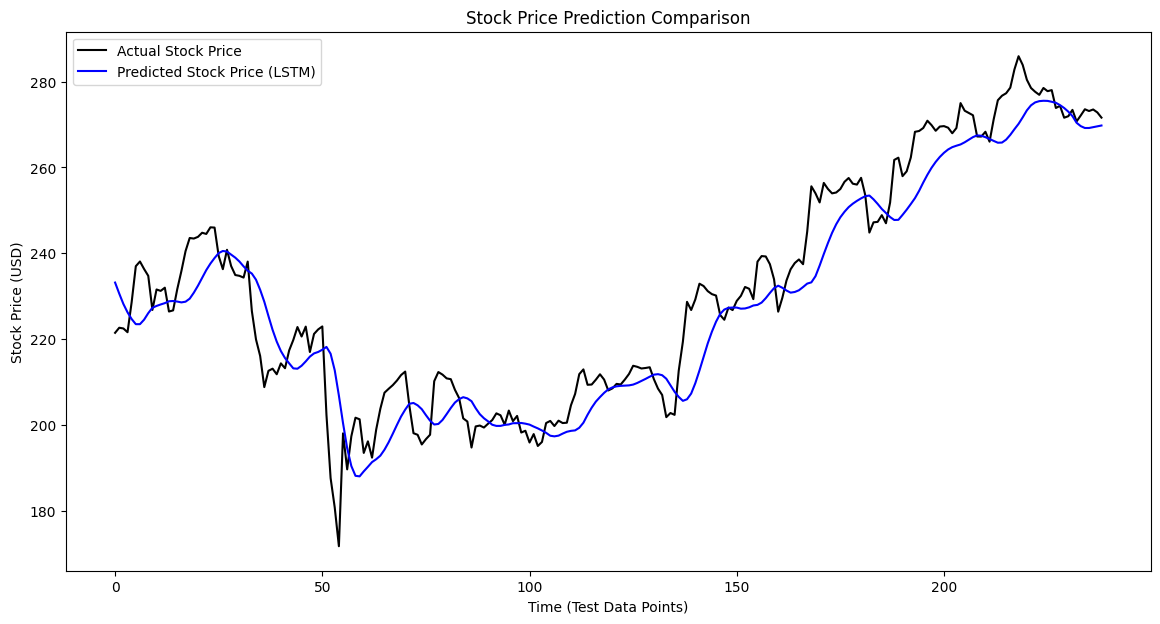

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. INVERSE TRANSFORM PREDICTIONS
# Since we scaled data in Week 2, we must reverse it to see actual dollar prices.
# Note: Use the scaler instance created in Week 2.
# The scaler was fitted on 5 columns: 'Open', 'High', 'Low', 'Close', 'Volume'.
# The 'Close' price is at index 3.
# We need to construct a 5-column array for inverse transformation.
lstm_predictions_actual = scaler.inverse_transform(
    np.concatenate([
        np.zeros((len(lstm_predictions), 3)),  # Placeholder for Open, High, Low
        lstm_predictions,                      # The predicted Close price
        np.zeros((len(lstm_predictions), 1))   # Placeholder for Volume
    ], axis=1)
)[:, 3]

y_test_actual = scaler.inverse_transform(
    np.concatenate([
        np.zeros((len(y_test_seq), 3)),       # Placeholder for Open, High, Low
        y_test_seq.reshape(-1, 1),             # The actual Close price
        np.zeros((len(y_test_seq), 1))         # Placeholder for Volume
    ], axis=1)
)[:, 3]

# 2. EVALUATION METRICS
def print_final_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- {name} Final Performance ---")
    print(f"MAE: ${mae:.2f}")
    print(f"RMSE: ${rmse:.2f}")
    print(f"R2 Score: {r2:.4f}\n")

print_final_metrics(y_test_actual, lstm_predictions_actual, "LSTM Model")

# 3. VISUALIZATION: ACTUAL VS PREDICTED
plt.figure(figsize=(14, 7))
plt.plot(y_test_actual, color='black', label='Actual Stock Price')
plt.plot(lstm_predictions_actual, color='blue', label='Predicted Stock Price (LSTM)')
plt.title('Stock Price Prediction Comparison')
plt.xlabel('Time (Test Data Points)')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.show()